# XES Modeling of the Fe(II) Spin-Crossover Cascade

Models the static Kbeta XES reference spectra of five spin states as sums of 4 Voigt profiles, then simulates the transient XES signal for a singlet -> triplet -> quintet spin-crossover cascade, including the eventual long-lifetime decay of the quintet state.

Physical background: `docs/physics/02_xes_spin_states.md` (the static reference model) and `docs/physics/03_ultrafast_pump_probe_kinetics.md` (the cascade kinetics).

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Run from the repository root and import `vlab_xray` from this repository's
# own `src/`, so that `data/` and `figures/` resolve identically no matter
# where Jupyter was started and an editable install of another copy of the
# package cannot shadow these sources.
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents)
            if (p / "src" / "vlab_xray").is_dir())
os.chdir(ROOT)
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from vlab_xray import io as vio
from vlab_xray.xes_model import rec_xes_4voigts
from vlab_xray.kinetics import (
    build_transient_xes_map,
    build_transient_xes_map_with_quintet_decay,
)

%matplotlib inline

## Simulate Static Reference Spectra

Text(0, 0.5, 'Intensity / arb. un.')

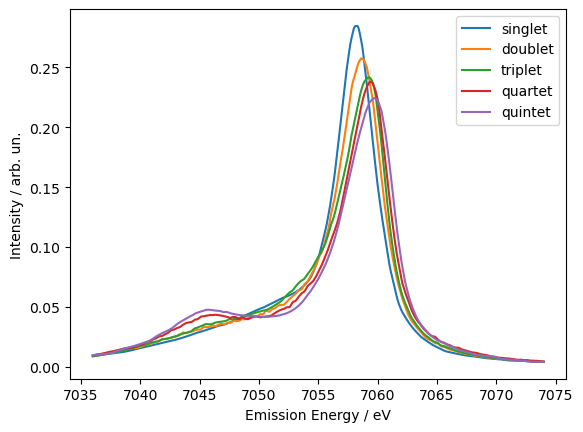

In [2]:
# Measured static XES reference spectra, one per spin state
reference_data = vio.load_xes_reference_spectra()
refs_es = reference_data.index.to_numpy()  # emission energy vector

plt.plot(reference_data)
plt.legend(reference_data.columns)
plt.xlabel('Emission Energy / eV')
plt.ylabel('Intensity / arb. un.')

In [3]:
# Sum-of-4-Voigts model for each reference spectrum, using fit parameters
# obtained in a separate fitting script
p_rec_refs = vio.load_xes_reference_fit_params()

singlet_model = rec_xes_4voigts(refs_es, p_rec_refs['singlet'])
doublet_model = rec_xes_4voigts(refs_es, p_rec_refs['doublet'])
triplet_model = rec_xes_4voigts(refs_es, p_rec_refs['triplet'])
quartet_model = rec_xes_4voigts(refs_es, p_rec_refs['quartet'])
quintet_model = rec_xes_4voigts(refs_es, p_rec_refs['quintet'])

Text(0, 0.5, 'Intensity / arb. un.')

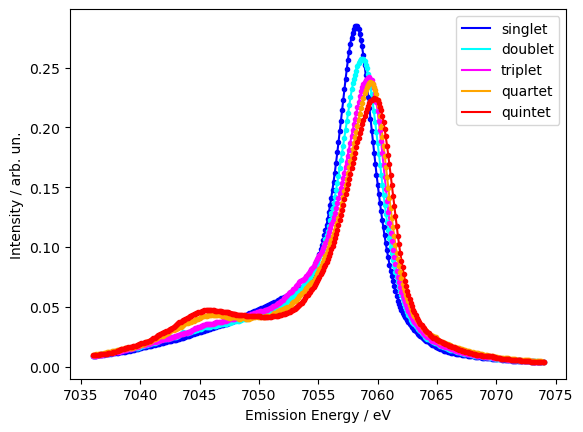

In [4]:
# Plot modeled spectra together with the data
plt.figure()
plt.plot(refs_es, singlet_model, color='blue')
plt.plot(refs_es, doublet_model, color='cyan')
plt.plot(refs_es, triplet_model, color='magenta')
plt.plot(refs_es, quartet_model, color='orange')
plt.plot(refs_es, quintet_model, color='red')

plt.plot(reference_data.singlet, '.', color='blue')
plt.plot(reference_data.doublet, '.', color='cyan')
plt.plot(reference_data.triplet, '.', color='magenta')
plt.plot(reference_data.quartet, '.', color='orange')
plt.plot(reference_data.quintet, '.', color='red')

plt.legend(reference_data.columns)
plt.xlabel('Emission Energy / eV')
plt.ylabel('Intensity / arb. un.')

Text(0.5, 190.7222222222222, 'Emission Energy / eV')

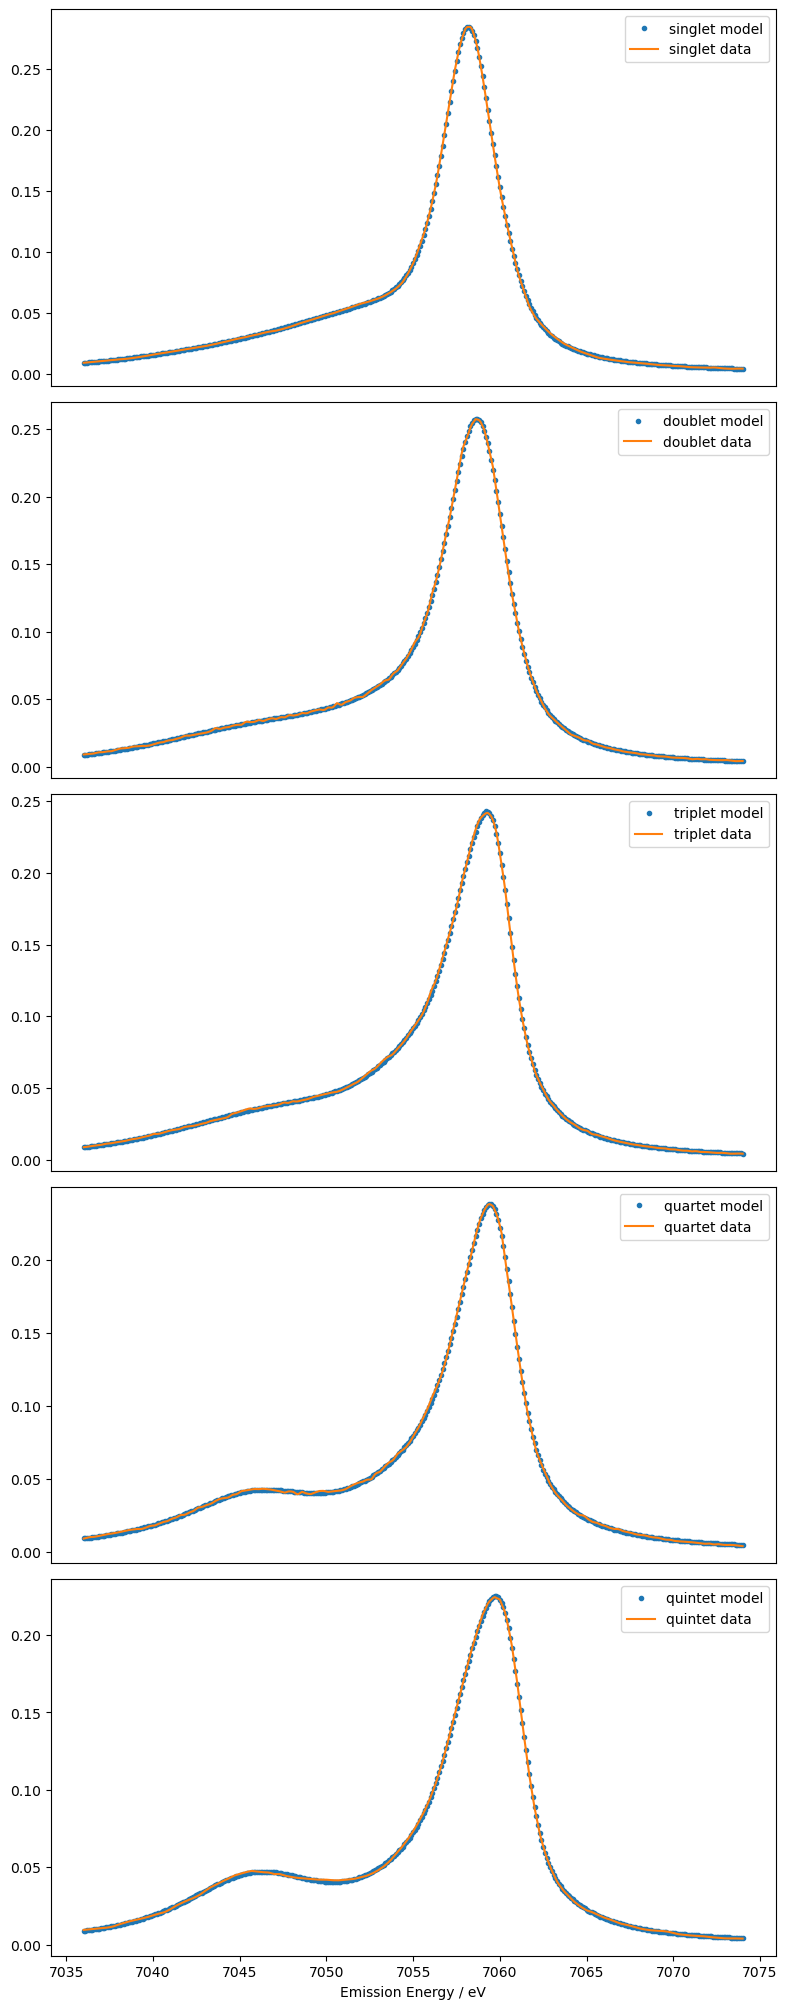

In [5]:
# Same comparison, one spin state per panel
plt.figure(figsize=(8, 20))
models = [singlet_model, doublet_model, triplet_model, quartet_model, quintet_model]
for i, name in enumerate(reference_data.columns):
    plt.subplot(5, 1, i + 1)
    plt.plot(refs_es, models[i], '.')
    plt.plot(reference_data[name])
    plt.legend([f'{name} model', f'{name} data'])
    if i < 4:
        plt.xticks([])
plt.tight_layout()
plt.xlabel('Emission Energy / eV')

## Simulate Time-Resolved Data

In [6]:
# Time-resolved (pump-probe) XES difference map; the loader converts the
# source file's picosecond delays to femtoseconds and labels the columns
# accordingly (see vlab_xray.io.load_time_resolved_xes).
timeresolved_data = vio.load_time_resolved_xes()
fxe_energies = timeresolved_data.index.to_numpy()
delay_fs = np.array([int(label.split()[0]) for label in timeresolved_data.columns])

## Kinetic Model: Singlet -> Triplet -> Quintet Cascade

The transient XES is modeled with a kinetic singlet -> triplet -> quintet cascade. Within this window the quintet state is treated as effectively infinitely long-lived; its eventual decay is added separately below. Parameters (`t0, I0, sigma, tau`) were obtained from a fit in a separate script -- see `docs/physics/03_ultrafast_pump_probe_kinetics.md`.

In [7]:
I0, t0, sigma, tau = 13.17100232, 50.44202757, 104.20065824, 93.90227357

# Evaluate the reference models on the time-resolved data's own energy grid
# (fxe_energies), not the reference-spectra grid (refs_es) used above --
# the two data files were not measured on identical energy axes.
singlet_fxe = rec_xes_4voigts(fxe_energies, p_rec_refs['singlet'])
triplet_fxe = rec_xes_4voigts(fxe_energies, p_rec_refs['triplet'])
quintet_fxe = rec_xes_4voigts(fxe_energies, p_rec_refs['quintet'])

data_model = build_transient_xes_map(
    singlet_fxe, triplet_fxe, quintet_fxe,
    delay_fs, t0=t0, i0=I0, sigma=sigma, tau=tau,
)

(7030.0, 7080.0)

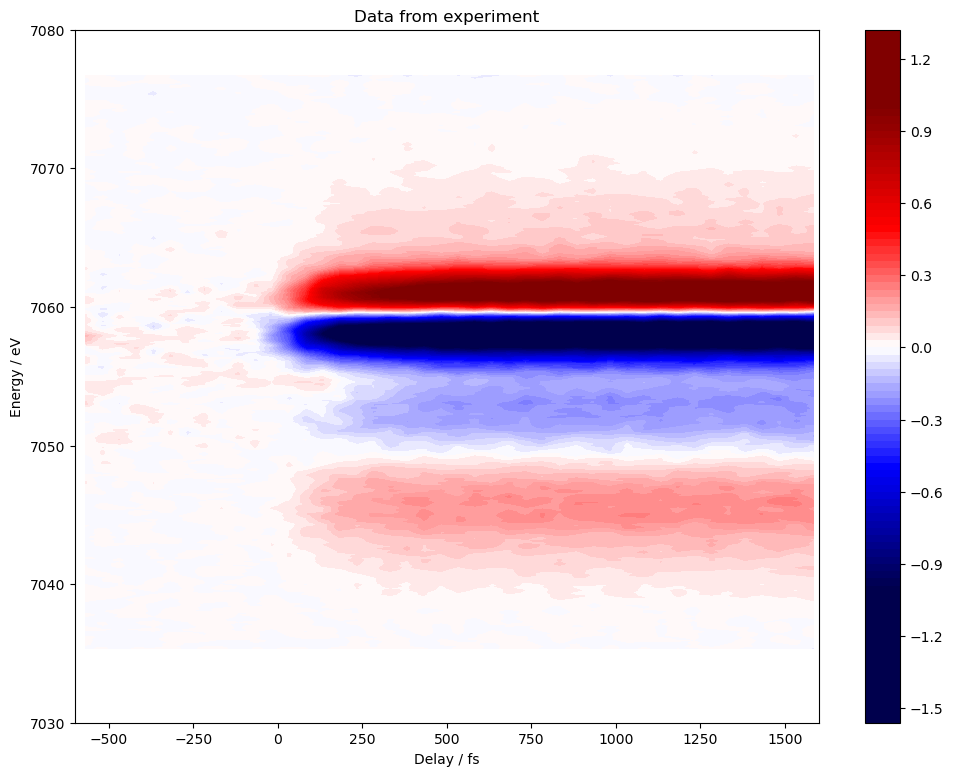

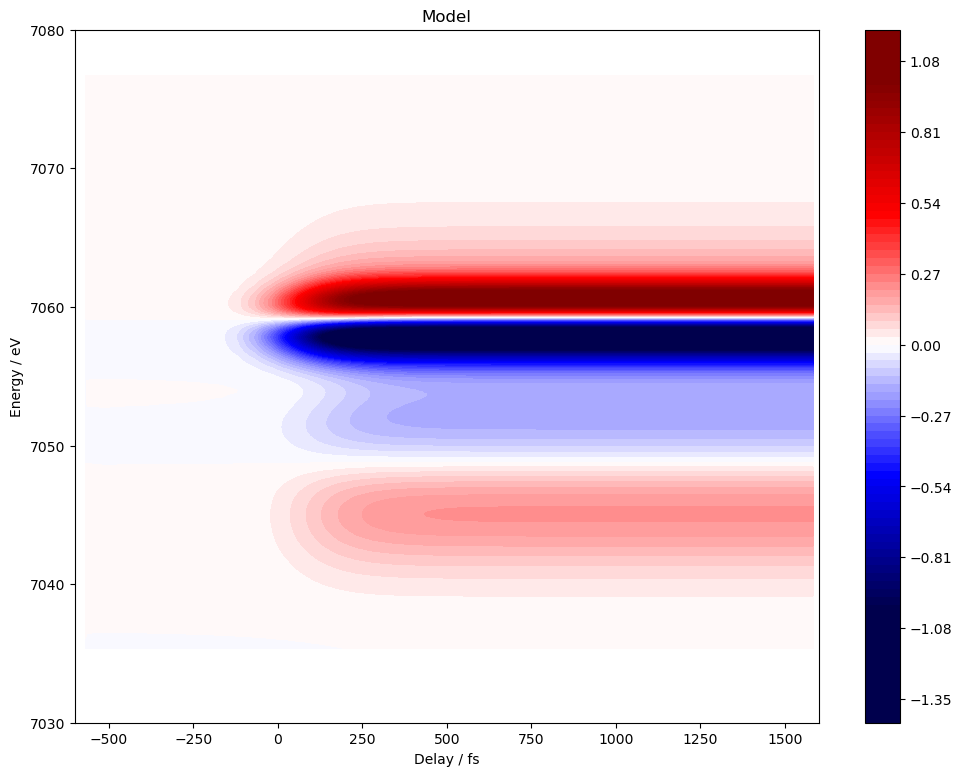

In [8]:
# Contour plot of measured data vs. model
plt.figure(figsize=(12, 9))
plt.title('Data from experiment')
plt.contourf(delay_fs, timeresolved_data.index, timeresolved_data.to_numpy(), 100, cmap='seismic', vmin=-1, vmax=1)
plt.xlabel('Delay / fs')
plt.ylabel('Energy / eV')
plt.colorbar()
plt.xlim([-600, 1600])
plt.ylim([7030, 7080])

plt.figure(figsize=(12, 9))
plt.title('Model')
plt.contourf(delay_fs, fxe_energies, data_model, 100, cmap='seismic', vmin=-1, vmax=1)
plt.xlabel('Delay / fs')
plt.ylabel('Energy / eV')
plt.colorbar()
plt.xlim([-600, 1600])
plt.ylim([7030, 7080])

Text(0.5, 0, 'Energy / eV')

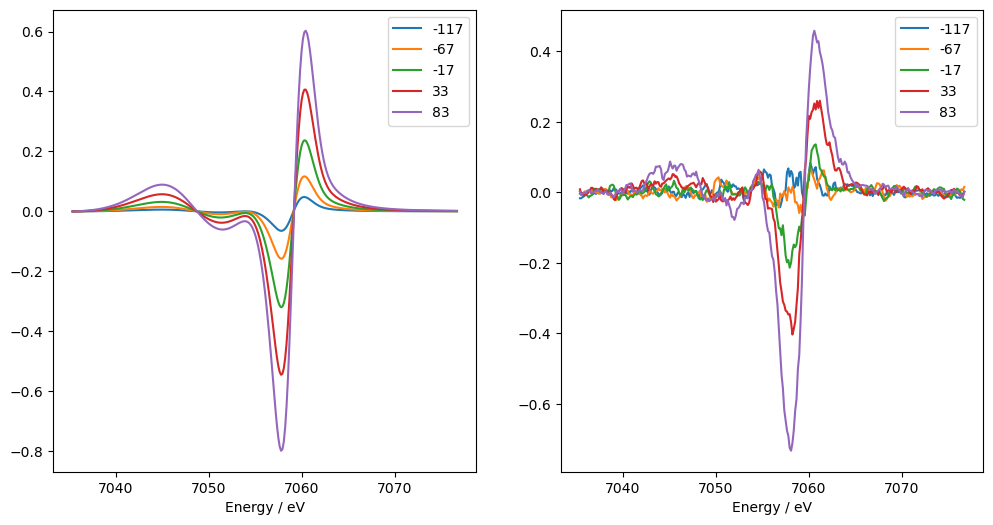

In [9]:
# A few transients at selected delays, model vs. data
plt.figure(figsize=(12, 6))
plt.subplot(121)
plt.plot(fxe_energies, data_model[:, 9:14])
plt.xlabel('Energy / eV')
plt.legend(delay_fs[9:14])
plt.subplot(122)
plt.plot(fxe_energies, timeresolved_data.to_numpy()[:, 9:14])
plt.legend(delay_fs[9:14])
plt.xlabel('Energy / eV')

## Exponential Decay of the Quintet State

Beyond the initial cascade window, the transient signal is frozen and decays back to zero (full ground-state recovery) with the quintet state's much longer lifetime -- see `kinetics.build_transient_xes_map_with_quintet_decay` and `docs/physics/03_ultrafast_pump_probe_kinetics.md`.

(7030.0, 7080.0)

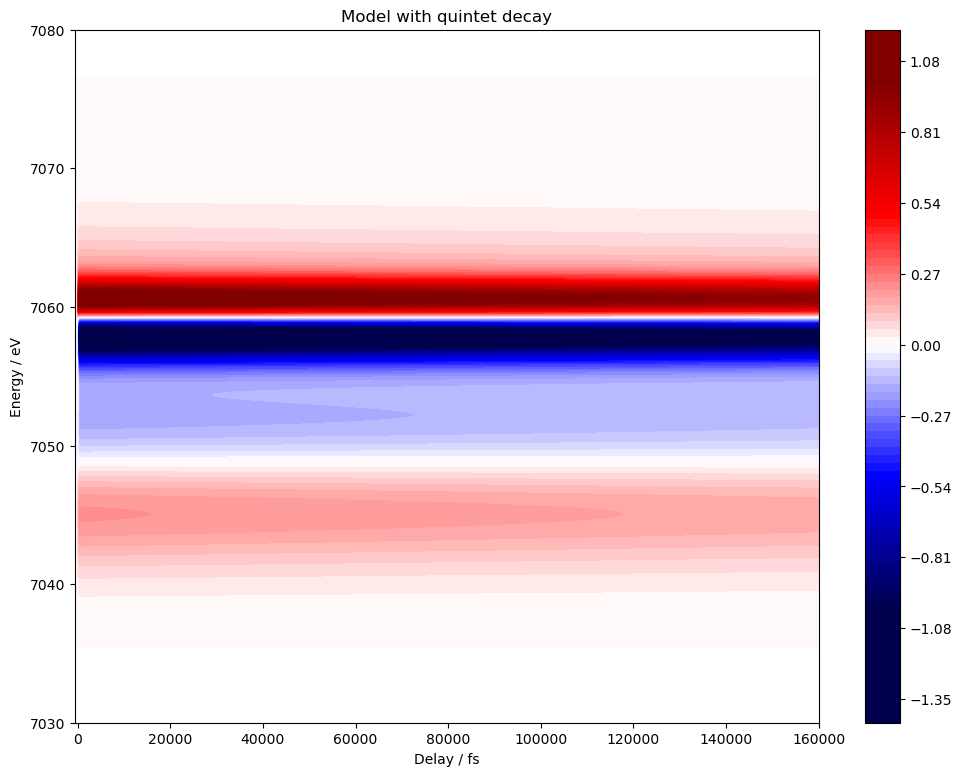

In [10]:
delays_fs_extended = np.arange(-10000, 500000, 10.0)
quintet_lifetime = 660_000  # fs (660 ps)

data_model_with_decay = build_transient_xes_map_with_quintet_decay(
    singlet_fxe, triplet_fxe, quintet_fxe,
    delays_fs_extended, t0=t0, i0=I0, sigma=sigma, tau=tau,
    quintet_lifetime=quintet_lifetime,
)

plt.figure(figsize=(12, 9))
plt.title('Model with quintet decay')
plt.contourf(delays_fs_extended, fxe_energies, data_model_with_decay, 100, cmap='seismic', vmin=-1, vmax=1)
plt.xlabel('Delay / fs')
plt.ylabel('Energy / eV')
plt.colorbar()
plt.xlim([-600, 160000])
plt.ylim([7030, 7080])